# BBox Comparison: MinerU vs Docling (top-5 images)

- **Left panel** — MinerU bboxes, drawn from the `*_middle.json` blocks where `type == "image"`
- **Right panel** — Docling bboxes, drawn from `doc.pictures[i].prov[0].bbox`
- Both panels render the same PDF page rasterized at 150 DPI, then overlay the bboxes with `PIL.ImageDraw`

In [1]:
import json
import fitz  # PyMuPDF
from PIL import Image, ImageDraw
import io
import numpy as np
from pathlib import Path
from IPython.display import display, Image as IPImage, Markdown

# ── paths ──────────────────────────────────────────────────────────────────────
try:
    from IPython import get_ipython
    ip = get_ipython()
    nb_path = Path(ip.kernel.shell.user_ns.get("__vsc_ipynb_file__", ""))
    nb_dir = nb_path.parent if nb_path.exists() else Path.cwd()
except Exception:
    nb_dir = Path.cwd()

PDF_PATH    = nb_dir / "data" / "pdf" / "arxiv" / "2403.20331v2.pdf"
PARSE_DIR   = nb_dir / "data" / "pdf" / "arxiv" / "mineru_output" / "2403.20331v2" / "auto"
MIDDLE_JSON = PARSE_DIR / "2403.20331v2_middle.json"

DPI        = 150
SCALE      = DPI / 72          # PyMuPDF default is 72 DPI
MAX_IMAGES = 5                  # show top-5 images only

MINERU_COLOR  = (220, 50,  50,  160)   # red  with alpha
DOCLING_COLOR = (50,  100, 220, 160)   # blue with alpha

# ── helper: rasterize one PDF page ─────────────────────────────────────────────
def render_page(pdf_doc, page_num: int, dpi: int = DPI) -> Image.Image:
    page = pdf_doc[page_num]
    mat  = fitz.Matrix(dpi / 72, dpi / 72)
    pix  = page.get_pixmap(matrix=mat, alpha=False)
    return Image.frombytes("RGB", (pix.width, pix.height), pix.samples)

# ── helper: draw semi-transparent colored rectangles ───────────────────────────
def draw_boxes(base_img: Image.Image, boxes_px: list[tuple], color_rgba: tuple) -> Image.Image:
    """boxes_px: list of (x0, y0, x1, y1) already in pixel coords."""
    overlay = Image.new("RGBA", base_img.size, (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)
    for box in boxes_px:
        draw.rectangle(box, outline=color_rgba[:3] + (255,), width=3)
        draw.rectangle(box, fill=color_rgba)
    return Image.alpha_composite(base_img.convert("RGBA"), overlay).convert("RGB")

# ── 1. Load MinerU middle.json ─────────────────────────────────────────────────
# Structure: {"pdf_info": [...page dicts...], ...}
# Each page dict has "preproc_blocks" list; image blocks have type == "image"
assert MIDDLE_JSON.exists(), f"MinerU middle.json not found: {MIDDLE_JSON}"
raw = json.loads(MIDDLE_JSON.read_text(encoding="utf-8"))
pdf_info = raw["pdf_info"]  # list of page dicts

mineru_by_page: dict[int, list] = {}

for page_dict in pdf_info:
    pno = page_dict.get("page_idx", 0)
    for blk in page_dict.get("preproc_blocks", []):
        if blk.get("type") == "image":
            bbox = blk.get("bbox")
            if bbox:
                mineru_by_page.setdefault(pno, []).append(bbox)

print(f"MinerU image blocks by page: { {k: len(v) for k, v in sorted(mineru_by_page.items())} }")

# ── 2. Load Docling document (re-use docling_result if already in kernel) ──────
try:
    doc = docling_result.document
    print("Re-using docling_result from kernel.")
except NameError:
    from docling.datamodel.base_models import InputFormat
    from docling.datamodel.pipeline_options import PdfPipelineOptions
    from docling.document_converter import DocumentConverter, PdfFormatOption
    pipeline_options = PdfPipelineOptions()
    pipeline_options.generate_picture_images = False
    converter = DocumentConverter(
        format_options={InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)}
    )
    docling_result = converter.convert(PDF_PATH)
    doc = docling_result.document
    print("Parsed with Docling.")

# Build per-page list of picture bboxes from Docling
# prov.bbox is in pts with CoordOrigin.BOTTOMLEFT by default
docling_by_page: dict[int, list] = {}
for pic in doc.pictures:
    if not pic.prov:
        continue
    prov = pic.prov[0]
    pno  = prov.page_no - 1   # Docling pages are 1-indexed
    docling_by_page.setdefault(pno, []).append(prov.bbox)

print(f"Docling picture bboxes by page: { {k: len(v) for k, v in sorted(docling_by_page.items())} }")

# ── 3. Find pages that have MinerU images, keep top-5 images total ─────────────
pdf_doc   = fitz.open(str(PDF_PATH))
seen_imgs = 0
pages_to_show: list[int] = []
for pno in sorted(mineru_by_page.keys()):
    n = len(mineru_by_page[pno])
    if n > 0:
        pages_to_show.append(pno)
        seen_imgs += n
        if seen_imgs >= MAX_IMAGES:
            break

print(f"\nPages to visualise: {pages_to_show}  (covering first {seen_imgs} MinerU images)")


MinerU image blocks by page: {0: 3, 3: 1, 6: 1, 20: 1, 22: 2, 23: 1, 24: 1, 25: 1, 26: 1, 27: 1, 28: 1, 29: 1, 30: 1, 31: 1, 32: 1, 33: 1}


/Users/hanhanwu/Documents/Github/Yokan/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[INFO] 2026-07-13 21:08:17,435 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-07-13 21:08:17,439 [RapidOCR] download_file.py:60: File exists and is valid: /Users/hanhanwu/Documents/Github/Yokan/.venv/lib/python3.14/site-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-07-13 21:08:17,440 [RapidOCR] main.py:63: Using /Users/hanhanwu/Documents/Github/Yokan/.venv/lib/python3.14/site-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-07-13 21:08:17,451 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-07-13 21:08:17,452 [RapidOCR] download_file.py:60: File exists and is valid: /Users/hanhanwu/Documents/Github/Yokan/.venv/lib/python3.14/site-packages/rapidocr/mo

Parsed with Docling.
Docling picture bboxes by page: {0: 1, 3: 1, 5: 1, 6: 1, 7: 1, 19: 1, 21: 2, 23: 2, 24: 2, 25: 2, 26: 2, 27: 2, 28: 1, 29: 1, 30: 1, 31: 1, 32: 1, 33: 1, 37: 1, 39: 1, 40: 1}

Pages to visualise: [0, 3, 6]  (covering first 5 MinerU images)


---
**Page 1** — MinerU (red, left) vs Docling (blue, right)

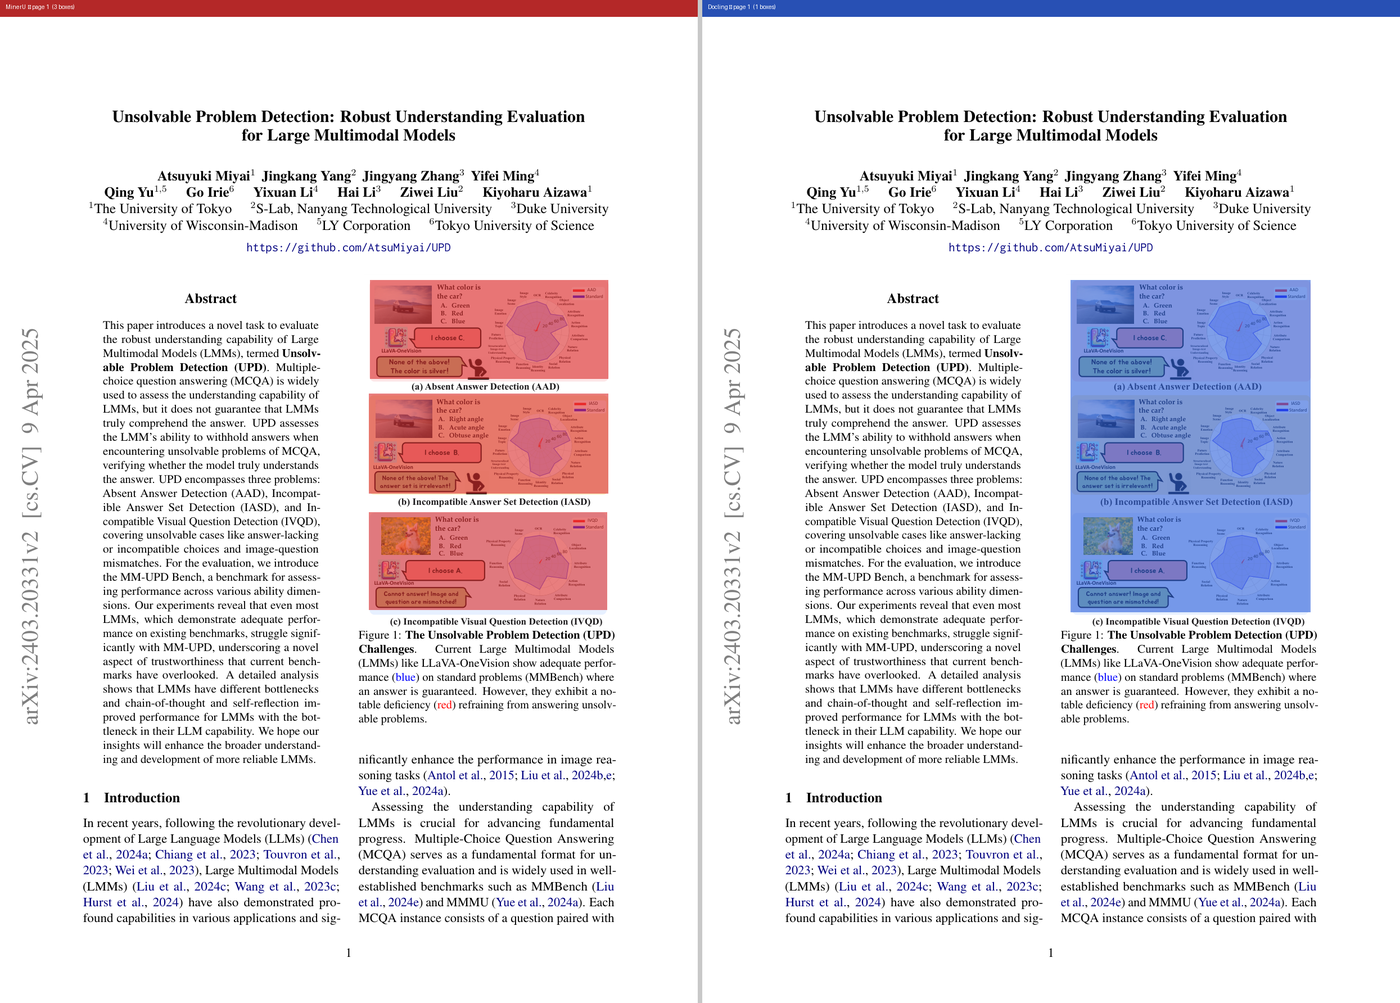

---
**Page 4** — MinerU (red, left) vs Docling (blue, right)

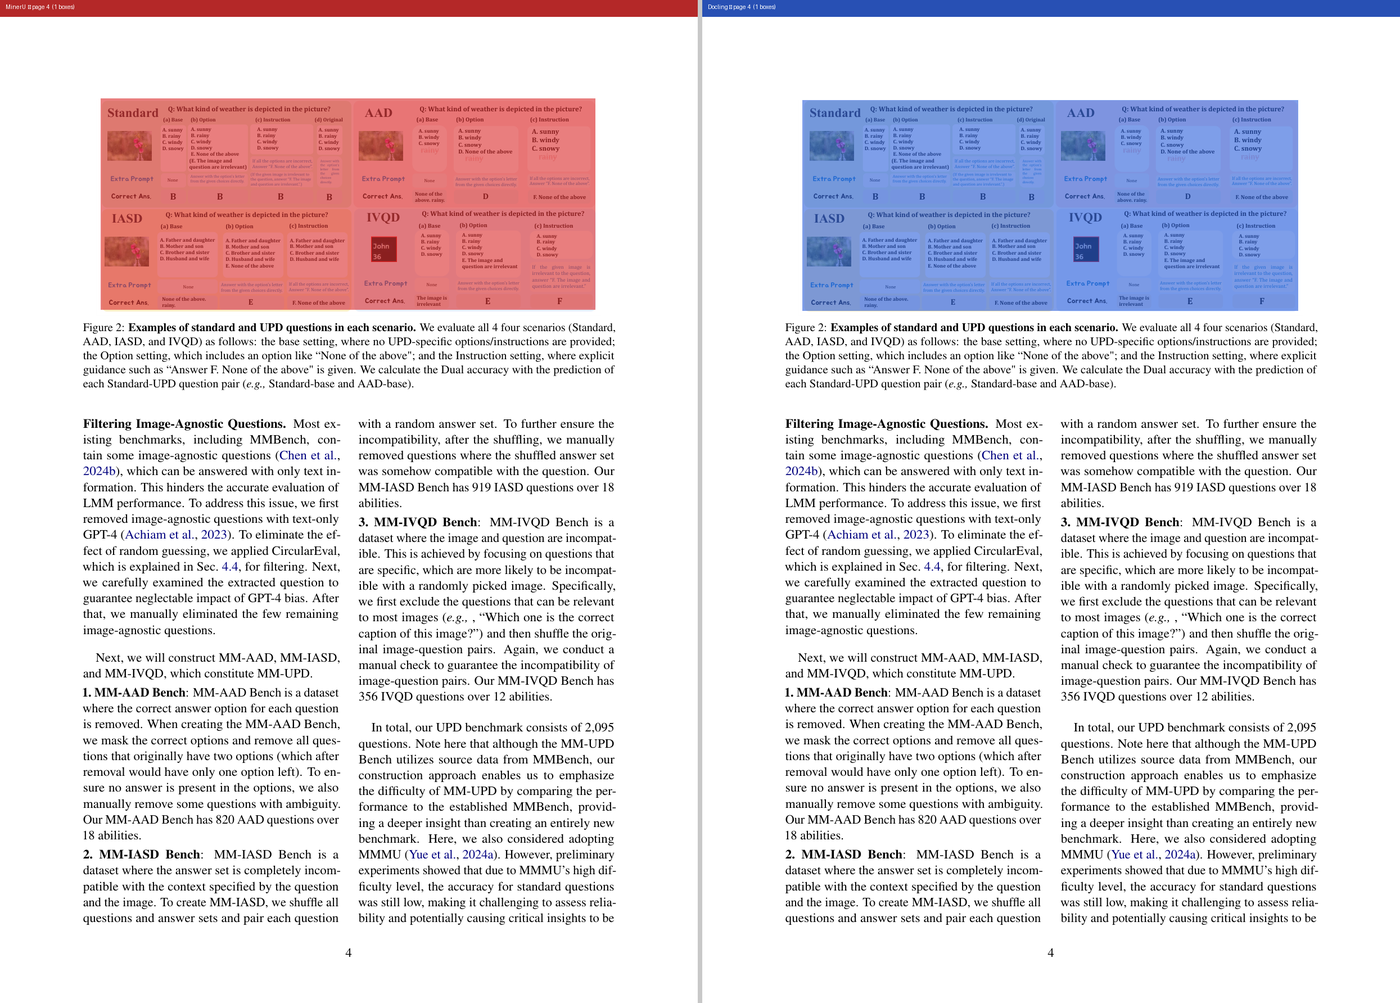

---
**Page 7** — MinerU (red, left) vs Docling (blue, right)

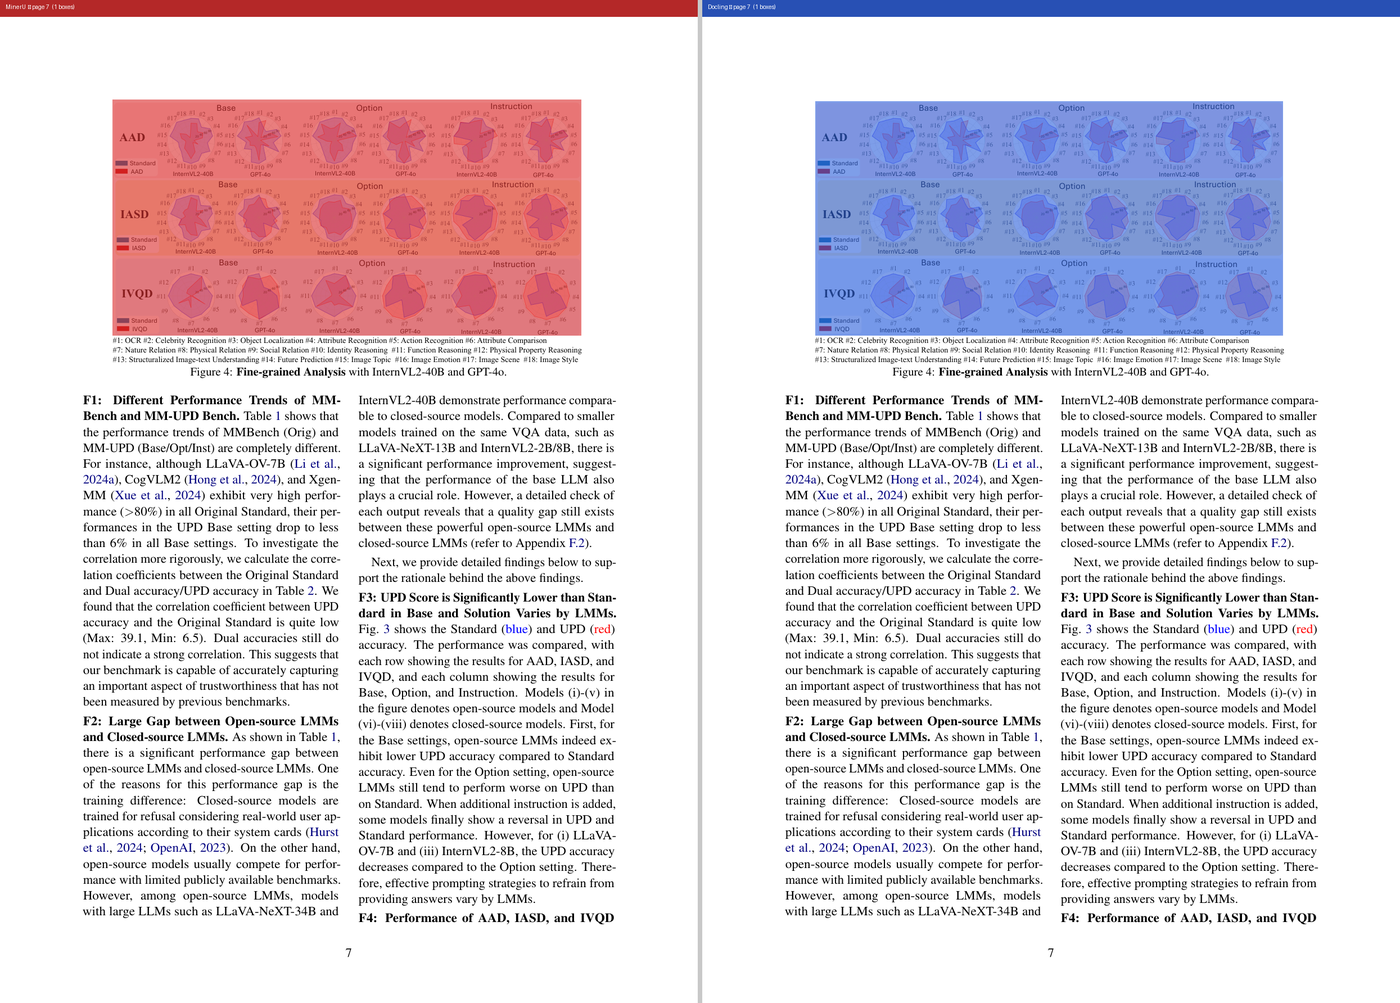

Done.


In [2]:
# ── 4. Render side-by-side panels for each qualifying page ─────────────────────
for pno in pages_to_show:
    page    = pdf_doc[pno]
    pw_pts  = page.rect.width   # page width in PDF points
    ph_pts  = page.rect.height  # page height in PDF points

    base_img = render_page(pdf_doc, pno)
    W, H = base_img.size

    # ── MinerU: bbox coords are [x0, y0, x1, y1] in PDF points, origin TOP-LEFT
    mineru_boxes_px = []
    for bbox in mineru_by_page.get(pno, []):
        x0, y0, x1, y1 = bbox
        # Scale pts → pixels
        px0 = int(x0 * SCALE)
        py0 = int(y0 * SCALE)
        px1 = int(x1 * SCALE)
        py1 = int(y1 * SCALE)
        mineru_boxes_px.append((px0, py0, px1, py1))

    # ── Docling: bbox uses CoordOrigin.BOTTOMLEFT  →  flip y-axis
    docling_boxes_px = []
    for bbox in docling_by_page.get(pno, []):
        # bbox attributes: l, t, r, b  (all in pts, origin bottom-left)
        l, t, r, b = bbox.l, bbox.t, bbox.r, bbox.b
        # Convert bottom-left origin to top-left origin:
        #   top-left-y  = page_height - top_of_bbox
        #   bot-left-y  = page_height - bottom_of_bbox
        py0 = int((ph_pts - t) * SCALE)
        py1 = int((ph_pts - b) * SCALE)
        px0 = int(l * SCALE)
        px1 = int(r * SCALE)
        # Ensure y0 < y1 after flip
        if py0 > py1:
            py0, py1 = py1, py0
        docling_boxes_px.append((px0, py0, px1, py1))

    # Draw bboxes on separate copies of the base image
    left_img  = draw_boxes(base_img.copy(), mineru_boxes_px,  MINERU_COLOR)
    right_img = draw_boxes(base_img.copy(), docling_boxes_px, DOCLING_COLOR)

    # Add a colour-coded legend strip at the top of each panel
    LEGEND_H = 30
    def add_legend(img: Image.Image, label: str, color: tuple) -> Image.Image:
        legend = Image.new("RGB", (img.width, LEGEND_H), color[:3])
        draw   = ImageDraw.Draw(legend)
        draw.text((10, 6), label, fill=(255, 255, 255))
        return Image.fromarray(
            np.vstack([np.array(legend), np.array(img)])
        )

    left_img  = add_legend(left_img,  f"MinerU  — page {pno+1}  ({len(mineru_boxes_px)} boxes)",  (180, 40, 40))
    right_img = add_legend(right_img, f"Docling — page {pno+1}  ({len(docling_boxes_px)} boxes)", (40, 80, 180))

    # Stitch left + right with a thin separator
    SEP = 8
    canvas = Image.new("RGB", (left_img.width * 2 + SEP, left_img.height), (200, 200, 200))
    canvas.paste(left_img,  (0, 0))
    canvas.paste(right_img, (left_img.width + SEP, 0))

    # Downscale for notebook display (keep aspect ratio, max width 1400 px)
    max_w = 1400
    if canvas.width > max_w:
        ratio  = max_w / canvas.width
        canvas = canvas.resize((max_w, int(canvas.height * ratio)), Image.LANCZOS)

    buf = io.BytesIO()
    canvas.save(buf, format="PNG")
    display(Markdown(f"---\n**Page {pno+1}** — MinerU (red, left) vs Docling (blue, right)"))
    display(IPImage(data=buf.getvalue()))

pdf_doc.close()
print("Done.")